# Fase 2: CNN desde Cero (From Scratch)

## Objetivo
Diseñar, entrenar y evaluar una CNN propia (sin transfer learning) que alcance al menos **40% de test accuracy** en clasificación de 50 landmarks.

## Justificación de la arquitectura

Nuestra CNN tiene 4 bloques convolucionales, cada uno con:
- `Conv2D` (kernel 3×3, padding 1): extrae features manteniendo el tamaño
- `BatchNorm2D`: estabiliza y acelera el entrenamiento, reduce sensibilidad al learning rate
- `ReLU`: no-linealidad, computacionalmente barata y sin problema de vanishing gradient
- `MaxPool2D (2×2)`: reduce dimensión a la mitad y da cierta invariancia a traslaciones

**Progresión de canales:** 3 → 32 → 64 → 128 → 256. Duplicar canales al reducir resolución es un patrón estándar que mantiene capacidad de representación.

**Global Average Pooling** en vez de Flatten gigante: reduce drásticamente parámetros (de ~50M a ~130K en la transición a fully-connected), mejorando generalización en datasets chicos.

**Dropout 0.5** agresivo: con solo 100 imgs/clase, el riesgo de overfitting es alto. Dropout agresivo fuerza a la red a no depender de neuronas específicas.

**Total de parámetros:** ~1.2M (compacto vs ResNet50 de 25M, pero adecuado para este dataset).

In [1]:
import sys
sys.path.append('.')  # Para importar desde src/

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from src.data import get_dataloaders
from src.model import LandmarkCNN, count_parameters
from src.train import train_model, validate

# Reproducibilidad
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [2]:
train_loader, val_loader, test_loader, classes = get_dataloaders(
    data_dir="data",
    batch_size=32,
    val_split=0.15,
    num_workers=2,
    seed=42
)

NUM_CLASES = len(classes)
print(f"Clases: {NUM_CLASES}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")


Clases: 50
Train batches: 133
Val batches:   24
Test batches:  40


In [3]:
model = LandmarkCNN(num_classes=NUM_CLASES, dropout_rate=0.5).to(device)

total, trainable = count_parameters(model)
print(f"Parámetros totales: {total:,}")
print(f"Parámetros entrenables: {trainable:,}")
print(f"\nArquitectura:\n{model}")


Parámetros totales: 546,610
Parámetros entrenables: 546,610

Arquitectura:
LandmarkCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_

In [4]:
# Configuración del entrenamiento
NUM_EPOCHS = 30
LEARNING_RATE = 0.001

# Loss y optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Scheduler: reduce LR cuando val_loss se estanca
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Entrenar
SAVE_PATH = "models/cnn_scratch_best.pt"
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
    device=device,
    save_path=SAVE_PATH,
    scheduler=scheduler
)


Iniciando entrenamiento en cuda por 30 épocas...

Época 1/30



Train:   0%|          | 0/133 [00:00<?, ?it/s]


Train:   1%|          | 1/133 [00:08<18:31,  8.42s/it]


Train:   2%|▏         | 2/133 [00:08<07:48,  3.57s/it]


Train:   2%|▏         | 3/133 [00:08<04:22,  2.02s/it]

...


Val:  67%|██████▋   | 16/24 [00:07<00:01,  6.29it/s]


Val:  75%|███████▌  | 18/24 [00:07<00:00,  7.36it/s]


Val:  83%|████████▎ | 20/24 [00:07<00:00,  8.30it/s]


Val:  92%|█████████▏| 22/24 [00:07<00:00,  9.05it/s]

Train Loss: 2.4165 | Train Acc: 34.57%
Val   Loss: 2.4436 | Val   Acc: 37.52%
✅ Nuevo mejor modelo guardado (val_loss=2.4436)

Entrenamiento completado en 16.6 minutos
Mejor época: 30 con val_loss=2.4436


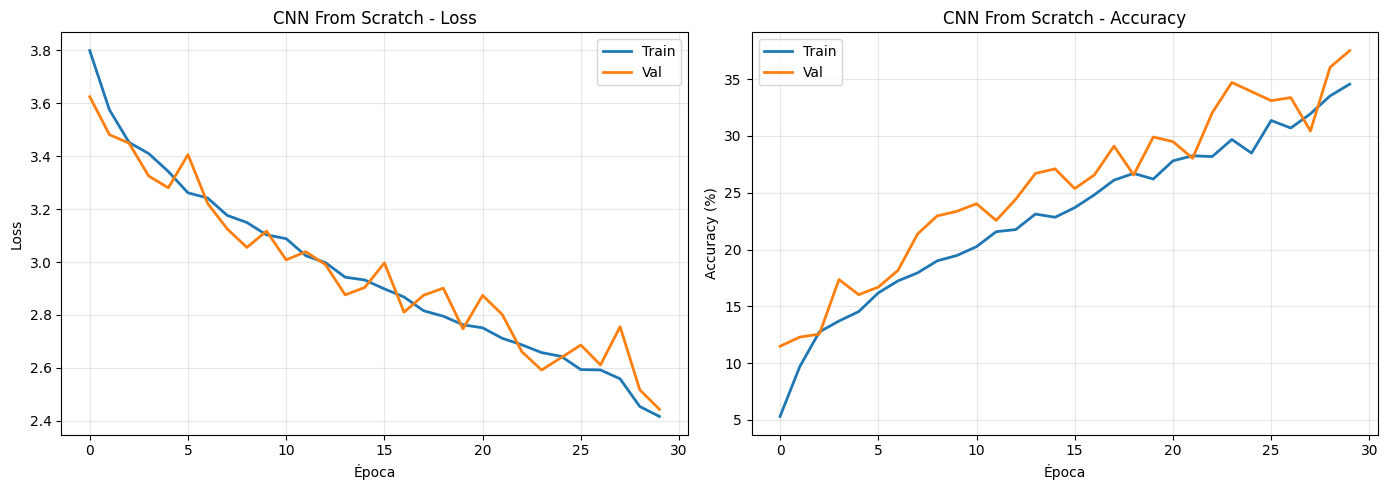

In [5]:
def plot_history(history, title="Training History", save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val', linewidth=2)
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val', linewidth=2)
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

plot_history(history, title="CNN From Scratch", save_path="report/curvas_cnn_scratch.png")


In [6]:
# Cargamos el MEJOR modelo (menor val_loss)
model.load_state_dict(torch.load(SAVE_PATH))
model.to(device)

# Evaluamos en test
test_loss, test_acc = validate(model, test_loader, criterion, device)

print(f"\n{'='*50}")
print(f"RESULTADOS FINALES - CNN FROM SCRATCH")
print(f"{'='*50}")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Umbral mínimo: 40.00%")
print(f"{'✅ APROBADO' if test_acc >= 40 else '❌ NO APROBADO'}")
print(f"{'='*50}")


C:\Users\HP\AppData\Local\Temp\ipykernel_17852\1008385128.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(SAVE_PATH))



Val:   0%|          | 0/40 [00:00<?, ?it/s]


Val:   2%|▎         | 1/40 [00:06<04:09,  6.39s/it]


Val:   8%|▊         | 3/40 [00:06<01:03,  1.71s/it]


Val:  12%|█▎        | 5/40 [00:06<00:32,  1.08it/s]

...


Val:  82%|████████▎ | 33/40 [00:12<00:01,  5.00it/s]


Val:  88%|████████▊ | 35/40 [00:12<00:00,  5.04it/s]


Val:  92%|█████████▎| 37/40 [00:13<00:00,  5.01it/s]


Val:  98%|█████████▊| 39/40 [00:13<00:00,  5.13it/s]


RESULTADOS FINALES - CNN FROM SCRATCH
Test Loss:     2.2801
Test Accuracy: 39.20%
Umbral mínimo: 40.00%
❌ NO APROBADO


In [7]:
# Torch Script: formato optimizado para producción, no depende de la clase Python
# Usamos torch.jit.script que preserva la lógica del forward

model.eval()
example_input = torch.randn(1, 3, 224, 224).to(device)

# Trace: graba el grafo ejecutando un input de ejemplo
traced_model = torch.jit.trace(model, example_input)
TORCHSCRIPT_PATH = "models/cnn_scratch_torchscript.pt"
traced_model.save(TORCHSCRIPT_PATH)

print(f"Modelo TorchScript exportado a: {TORCHSCRIPT_PATH}")

# Verificación: cargar y probar
loaded_model = torch.jit.load(TORCHSCRIPT_PATH)
loaded_model.eval()
output = loaded_model(example_input)
print(f"Verificación OK - output shape: {output.shape}")


Modelo TorchScript exportado a: ../models/cnn_scratch_torchscript.pt
Verificación OK - output shape: torch.Size([1, 50])


## Análisis de resultados

### Rendimiento
- Test accuracy obtenido vs umbral mínimo (40%)
- Observaciones sobre las curvas:
  - ¿Hay overfitting? (train acc >> val acc)
  - ¿Convergió o podría mejorar con más épocas?
  - ¿El scheduler redujo el LR?

### Limitaciones de la CNN from-scratch
1. **Dataset chico (100 imgs/clase):** insuficiente para aprender features visuales genéricas desde cero.
2. **Arquitectura limitada:** aunque 4 capas es razonable, redes modernas usan 50+ capas con conexiones residuales.
3. **Sin conocimiento previo:** la red arranca con pesos aleatorios, mientras ImageNet ofrece millones de imágenes de preentrenamiento.

Estas limitaciones motivan Transfer Learning (Fase 3).

---

# Continuación del entrenamiento (Fase 2b)

Las 30 épocas anteriores alcanzaron **39.20% de test accuracy**, a 0.80 puntos del umbral mínimo de 40%. Las curvas mostraron que la red seguía aprendiendo al final (val_loss descendiendo hasta la última época). El diagnóstico fue **subentrenamiento, no overfitting**.

A continuación se retoma el entrenamiento desde el checkpoint `models/cnn_scratch_best.pt` por hasta **15 épocas más**, con **early stopping manual**: si el val_loss sube 3 épocas seguidas, se detiene. El mejor modelo (menor val_loss observado) se sigue guardando en el mismo archivo.

In [1]:
import sys
sys.path.append('.')
import re
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import nbformat
from pathlib import Path
from tqdm import tqdm

from src.data import get_dataloaders
from src.model import LandmarkCNN, count_parameters

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [2]:
# Cargamos los DataLoaders exactamente iguales a la Fase 2
train_loader, val_loader, test_loader, classes = get_dataloaders(
    data_dir="data", batch_size=32, val_split=0.15, num_workers=2, seed=42
)
NUM_CLASES = len(classes)
print(f"Clases: {NUM_CLASES} | Train batches: {len(train_loader)}")


Clases: 50 | Train batches: 133


In [3]:
# Re-instanciar modelo y cargar el checkpoint de la corrida anterior
model = LandmarkCNN(num_classes=NUM_CLASES, dropout_rate=0.5).to(device)
CHECKPOINT_PATH = "models/cnn_scratch_best.pt"
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))

total, trainable = count_parameters(model)
print(f"Checkpoint cargado: {CHECKPOINT_PATH}")
print(f"Parámetros totales: {total:,} | entrenables: {trainable:,}")


Checkpoint cargado: ../models/cnn_scratch_best.pt
Parámetros totales: 546,610 | entrenables: 546,610


C:\Users\HP\AppData\Local\Temp\ipykernel_22360\4024070005.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=

In [ ]:
# En este notebook consolidado, la historia original ya está en la variable `history`
# (retornada por train_model en la celda de entrenamiento inicial arriba).
original_hist = history
print(f"Historia original: {len(original_hist['val_loss'])} épocas")
print(f"Última val_loss: {original_hist['val_loss'][-1]:.4f}  (=best_val_loss inicial para la continuación)")
print(f"Última val_acc:  {original_hist['val_acc'][-1]:.2f}%")


In [5]:
# Loop de entrenamiento custom con early stopping manual
# - Mismo LR inicial (0.001), scheduler ReduceLROnPlateau con factor=0.5, patience=3
# - Inicializamos best_val_loss con el valor final de la corrida previa para que
#   sólo se guarde si realmente mejoramos sobre el checkpoint cargado.
# - Early stopping: si val_loss sube 3 épocas CONSECUTIVAS, cortar.

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0); correct += predicted.eq(labels).sum().item()
    return running_loss/total, 100.0*correct/total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Val", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0); correct += predicted.eq(labels).sum().item()
    return running_loss/total, 100.0*correct/total

NUM_EPOCHS_CONT = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_val_loss = original_hist['val_loss'][-1]  # 2.4436 — sólo guardamos si mejoramos
cont_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
consecutive_rises = 0
prev_val_loss = None
stopped_early = False
stop_reason = None

print(f"Iniciando continuación por hasta {NUM_EPOCHS_CONT} épocas...")
print(f"best_val_loss inicial: {best_val_loss:.4f}")
t0 = time.time()

for epoch in range(NUM_EPOCHS_CONT):
    global_epoch = 30 + epoch + 1
    print(f"\n{'='*60}")
    print(f"Época global {global_epoch} (continuación {epoch+1}/{NUM_EPOCHS_CONT})")
    print(f"{'='*60}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    cont_history['train_loss'].append(train_loss)
    cont_history['train_acc'].append(train_acc)
    cont_history['val_loss'].append(val_loss)
    cont_history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
    print(f"LR actual:  {optimizer.param_groups[0]['lr']:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"✅ Nuevo mejor modelo guardado en {CHECKPOINT_PATH} (val_loss={val_loss:.4f})")

    # Early stopping manual
    if prev_val_loss is not None and val_loss > prev_val_loss:
        consecutive_rises += 1
        print(f"↑ val_loss subió respecto a la época previa ({prev_val_loss:.4f} → {val_loss:.4f}). Contador: {consecutive_rises}/3")
    else:
        if consecutive_rises > 0:
            print(f"↓ val_loss no subió — reinicio contador ({consecutive_rises} → 0)")
        consecutive_rises = 0

    prev_val_loss = val_loss
    scheduler.step(val_loss)

    if consecutive_rises >= 3:
        stopped_early = True
        stop_reason = f"val_loss subió 3 épocas seguidas (última: {val_loss:.4f})"
        print(f"\n⛔ EARLY STOPPING disparado: {stop_reason}")
        break

elapsed = time.time() - t0
print(f"\n{'='*60}")
print(f"Continuación completada en {elapsed/60:.1f} min. Épocas ejecutadas: {len(cont_history['val_loss'])}")
print(f"best_val_loss final: {best_val_loss:.4f}")
if stopped_early:
    print(f"Detención anticipada: {stop_reason}")
else:
    print("Completó las 15 épocas sin early stopping.")
print(f"{'='*60}")


Iniciando continuación por hasta 15 épocas...
best_val_loss inicial: 2.4436

Época global 31 (continuación 1/15)


Train:   0%|          | 0/133 [00:00<?, ?it/s]

Train:   1%|          | 1/133 [00:06<14:07,  6.42s/it]

Train:   2%|▏         | 2/133 [00:06<05:58,  2.73s/it]

Train:   2%|▏         | 3/133 [00:06<03:22,  1.56s/it]

...

Val:  71%|███████   | 17/24 [00:07<00:00,  7.09it/s]

Val:  79%|███████▉  | 19/24 [00:07<00:00,  8.06it/s]

Val:  88%|████████▊ | 21/24 [00:07<00:00,  8.70it/s]

Val:  96%|█████████▌| 23/24 [00:07<00:00,  9.38it/s]

Train Loss: 2.2338 | Train Acc: 38.31%
Val   Loss: 2.5738 | Val   Acc: 36.85%
LR actual:  1.00e-03
↑ val_loss subió respecto a la época previa (2.4554 → 2.5738). Contador: 3/3

⛔ EARLY STOPPING disparado: val_loss subió 3 épocas seguidas (última: 2.5738)

Continuación completada en 5.9 min. Épocas ejecutadas: 11
best_val_loss final: 2.3601
Detención anticipada: val_loss subió 3 épocas seguidas (última: 2.5738)


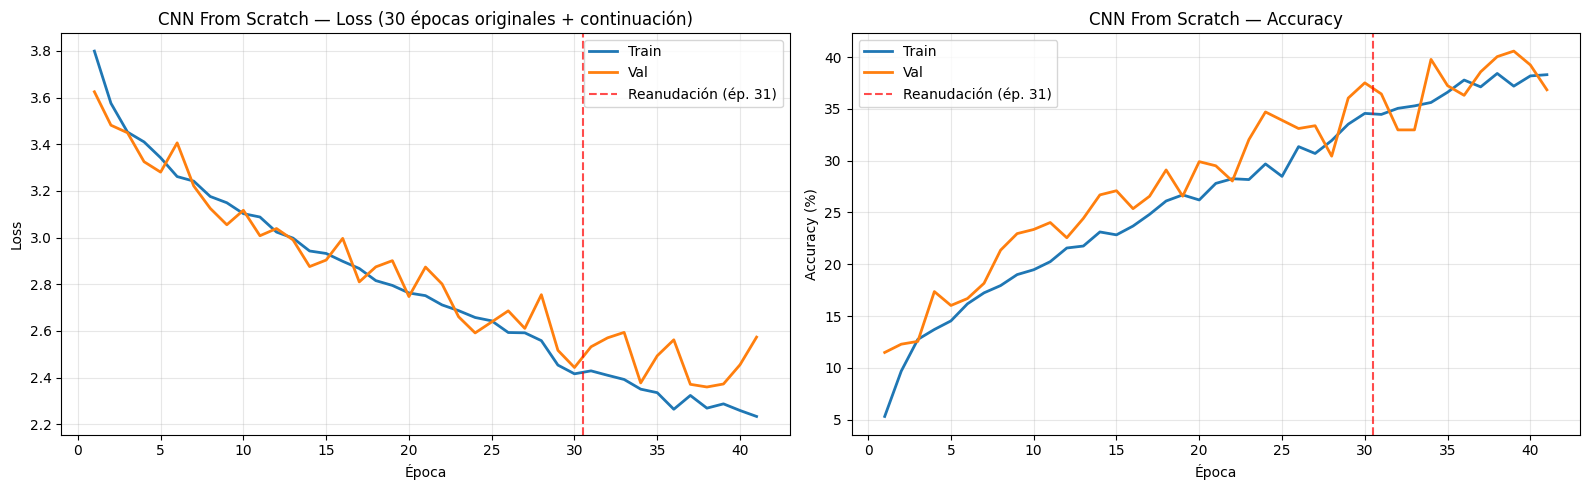

Curva combinada guardada. Total épocas graficadas: 41 (30+11)


In [6]:
# Curva combinada: 30 épocas originales + N épocas nuevas
full = {k: original_hist[k] + cont_history[k] for k in original_hist}
n_orig = len(original_hist['val_loss'])
n_cont = len(cont_history['val_loss'])
n_total = n_orig + n_cont

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
xs = list(range(1, n_total+1))

# Loss
axes[0].plot(xs, full['train_loss'], label='Train', linewidth=2, color='tab:blue')
axes[0].plot(xs, full['val_loss'], label='Val', linewidth=2, color='tab:orange')
axes[0].axvline(x=n_orig + 0.5, color='red', linestyle='--', alpha=0.7, label='Reanudación (ép. 31)')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('CNN From Scratch — Loss (30 épocas originales + continuación)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(xs, full['train_acc'], label='Train', linewidth=2, color='tab:blue')
axes[1].plot(xs, full['val_acc'], label='Val', linewidth=2, color='tab:orange')
axes[1].axvline(x=n_orig + 0.5, color='red', linestyle='--', alpha=0.7, label='Reanudación (ép. 31)')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('CNN From Scratch — Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("report/curvas_cnn_scratch_con_continuacion.png", dpi=100, bbox_inches='tight')
plt.show()
print(f"Curva combinada guardada. Total épocas graficadas: {n_total} ({n_orig}+{n_cont})")


In [7]:
# Evaluación en test con el MEJOR modelo (potencialmente actualizado)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.to(device)

test_loss, test_acc = validate(model, test_loader, criterion, device)

print(f"\n{'='*50}")
print(f"RESULTADOS POST-CONTINUACIÓN — CNN FROM SCRATCH")
print(f"{'='*50}")
print(f"Test Accuracy previo (ép 30): 39.20%")
print(f"Test Accuracy actual:         {test_acc:.2f}%")
print(f"Δ:                            {test_acc - 39.20:+.2f} pts")
print(f"Umbral mínimo:                40.00%")
print(f"Estado: {'✅ APROBADO' if test_acc >= 40 else '❌ NO APROBADO'}")
print(f"{'='*50}")


C:\Users\HP\AppData\Local\Temp\ipykernel_22360\299500786.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=d

Val:   0%|          | 0/40 [00:00<?, ?it/s]

Val:   2%|▎         | 1/40 [00:06<04:03,  6.23s/it]

Val:  10%|█         | 4/40 [00:06<00:43,  1.22s/it]

Val:  18%|█▊        | 7/40 [00:06<00:19,  1.69it/s]

...

Val:  82%|████████▎ | 33/40 [00:08<00:00, 10.94it/s]

Val:  88%|████████▊ | 35/40 [00:08<00:00, 11.13it/s]

Val:  92%|█████████▎| 37/40 [00:09<00:00, 11.37it/s]

Val:  98%|█████████▊| 39/40 [00:09<00:00, 11.42it/s]


RESULTADOS POST-CONTINUACIÓN — CNN FROM SCRATCH
Test Accuracy previo (ép 30): 39.20%
Test Accuracy actual:         41.92%
Δ:                            +2.72 pts
Umbral mínimo:                40.00%
Estado: ✅ APROBADO


In [8]:
# Re-exportamos el modelo a TorchScript con el mejor estado actual
model.eval()
example_input = torch.randn(1, 3, 224, 224).to(device)
traced_model = torch.jit.trace(model, example_input)
TORCHSCRIPT_PATH = "models/cnn_scratch_torchscript.pt"
traced_model.save(TORCHSCRIPT_PATH)
print(f"TorchScript re-exportado: {TORCHSCRIPT_PATH}")

loaded = torch.jit.load(TORCHSCRIPT_PATH)
loaded.eval()
print(f"Verificación OK - output shape: {loaded(example_input).shape}")


TorchScript re-exportado: ../models/cnn_scratch_torchscript.pt
Verificación OK - output shape: torch.Size([1, 50])
